# Notebook 03 - Compare 2D vs 3D vs Fusion

Objectives of this notebook:

1. Read JSON results after training.

2. Compare 2D, 3D, and Fusion 2D+3D.

3. Display Accuracy, F1 Macro, and F1 for each class.

4. Draw a comparison graph.

5. Draw a confusion matrix.

6. Create a concise conclusion for the report.

In [17]:
from pathlib import Path
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1]

print("Notebook dir:", NOTEBOOK_DIR)
print("Project root:", PROJECT_ROOT)

Notebook dir: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\notebooks
Project root: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH


In [18]:
RESULT_FILES = [
    {
        "task": "Binary",
        "model": "2D",
        "path": PROJECT_ROOT / "phase1_2d_baseline" / "outputs" / "training_2d" / "results_2d_binary.json",
    },
    {
        "task": "Binary",
        "model": "3D",
        "path": PROJECT_ROOT / "phase2_3d_upgrade" / "outputs" / "training_3d" / "results_3d_binary_cnn_lstm.json",
    },
    {
        "task": "Binary",
        "model": "Fusion 2D+3D",
        "path": PROJECT_ROOT / "phase2_3d_upgrade" / "outputs" / "training_fusion_2d3d" / "results_fusion_2d3d_binary.json",
    },
    {
        "task": "Action",
        "model": "2D",
        "path": PROJECT_ROOT / "phase1_2d_baseline" / "outputs" / "training_2d" / "results_2d_action.json",
    },
    {
        "task": "Action",
        "model": "3D",
        "path": PROJECT_ROOT / "phase2_3d_upgrade" / "outputs" / "training_3d" / "results_3d_action_cnn_lstm.json",
    },
    {
        "task": "Action",
        "model": "Fusion 2D+3D",
        "path": PROJECT_ROOT / "phase2_3d_upgrade" / "outputs" / "training_fusion_2d3d" / "results_fusion_2d3d_action.json",
    },
]

for item in RESULT_FILES:
    print(item["task"], item["model"], item["path"], "Exists:", item["path"].exists())

Binary 2D c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase1_2d_baseline\outputs\training_2d\results_2d_binary.json Exists: True
Binary 3D c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\outputs\training_3d\results_3d_binary_cnn_lstm.json Exists: True
Binary Fusion 2D+3D c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\outputs\training_fusion_2d3d\results_fusion_2d3d_binary.json Exists: True
Action 2D c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase1_2d_baseline\outputs\training_2d\results_2d_action.json Exists: True
Action 3D c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\outputs\training_3d\results_3d_action_cnn_lstm.json Exists: True
Action Fusion 2D+3D c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\outputs\training_fusion_2d3d\results_fusion_2d3d_action.json Exists: True


In [19]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


records = []

for item in RESULT_FILES:
    if not item["path"].exists():
        print("Missing:", item["path"])
        continue

    data = load_json(item["path"])

    records.append({
        "task": item["task"],
        "model": item["model"],
        "data": data,
    })

print("Loaded records:", len(records))

Loaded records: 6


In [20]:
def get_accuracy(data):
    return data.get("final_test_accuracy", data.get("best_accuracy"))


def get_macro_f1(data):
    return data.get("final_test_macro_f1", data.get("best_f1"))


def get_report_dict(data):
    report = data.get("classification_report")

    if isinstance(report, dict):
        return report

    return {}


def get_class_metric(data, class_name, metric):
    report = get_report_dict(data)

    if class_name not in report:
        return np.nan

    return report[class_name].get(metric, np.nan)


def get_confusion_matrix(data):
    return np.array(data.get("confusion_matrix", []))


def fmt4(x):
    if x is None or pd.isna(x):
        return "N/A"

    return f"{x:.4f}"

In [21]:
summary_rows = []

for r in records:
    data = r["data"]

    summary_rows.append({
        "Task": r["task"],
        "Model": r["model"],
        "Model Type": data.get("model_type", "N/A"),
        "Normalization": data.get("normalization", "N/A"),
        "Input Dim": data.get("input_dim", "N/A"),
        "Sequence Length": data.get("sequence_length", "N/A"),
        "Stride": data.get("stride", "N/A"),
        "Best Epoch": data.get("best_epoch", "N/A"),
        "Accuracy": get_accuracy(data),
        "Macro F1": get_macro_f1(data),
        "Train Sequences": data.get("train_sequences", "N/A"),
        "Test Sequences": data.get("test_sequences", "N/A"),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Task,Model,Model Type,Normalization,Input Dim,Sequence Length,Stride,Best Epoch,Accuracy,Macro F1,Train Sequences,Test Sequences
0,Binary,2D,CNN1D_BiLSTM_2D,per_frame_xy_mean_std,40,60,15,19,0.923806,0.914998,21545,5486
1,Binary,3D,CNN_LSTM_3D_same_as_2D_phase1,per_frame_xyz_mean_std,59,60,15,23,0.927805,0.914643,16022,4100
2,Binary,Fusion 2D+3D,CNN_LSTM_FUSION_2D_3D,2d_per_frame_xy_mean_std__3d_precomputed_norma...,99,60,15,24,0.940732,0.931041,16022,4100
3,Action,2D,CNN1D_BiLSTM_2D,per_frame_xy_mean_std,40,60,15,17,0.960891,0.946371,14221,3861
4,Action,3D,CNN_LSTM_3D_same_as_2D_phase1,per_frame_xyz_mean_std,59,60,15,17,0.938234,0.907491,11232,2979
5,Action,Fusion 2D+3D,CNN_LSTM_FUSION_2D_3D,2d_per_frame_xy_mean_std__3d_precomputed_norma...,99,60,15,27,0.969117,0.953245,11232,2979


In [22]:
binary_rows = []

for r in records:
    if r["task"] != "Binary":
        continue

    data = r["data"]

    binary_rows.append({
        "Model": f'{r["model"]} Binary',
        "Accuracy": get_accuracy(data),
        "Macro F1": get_macro_f1(data),
        "Fall Precision": get_class_metric(data, "Fall", "precision"),
        "Fall Recall": get_class_metric(data, "Fall", "recall"),
        "Fall F1": get_class_metric(data, "Fall", "f1-score"),
    })

binary_df = pd.DataFrame(binary_rows)
binary_df

,Model,Accuracy,Macro F1,Fall Precision,Fall Recall,Fall F1
0,2D Binary,0.923806,0.914998,0.871240,0.904658,0.887634
1,3D Binary,0.927805,0.914643,NaN,NaN,NaN
2,Fusion 2D+3D Binary,0.940732,0.931041,0.899225,0.911233,0.905189


In [23]:
action_rows = []

for r in records:
    if r["task"] != "Action":
        continue

    data = r["data"]

    action_rows.append({
        "Model": f'{r["model"]} Action',
        "Accuracy": get_accuracy(data),
        "Macro F1": get_macro_f1(data),
        "Sitting F1": get_class_metric(data, "Sitting", "f1-score"),
        "Sleeping F1": get_class_metric(data, "Sleeping", "f1-score"),
        "Standing F1": get_class_metric(data, "Standing", "f1-score"),
        "Walking F1": get_class_metric(data, "Walking", "f1-score"),
    })

action_df = pd.DataFrame(action_rows)
action_df

,Model,Accuracy,Macro F1,Sitting F1,Sleeping F1,Standing F1,Walking F1
0,2D Action,0.960891,0.946371,0.928973,0.933029,0.926009,0.997471
1,3D Action,0.938234,0.907491,NaN,NaN,NaN,NaN
2,Fusion 2D+3D Action,0.969117,0.953245,0.933642,0.959700,0.922314,0.997324


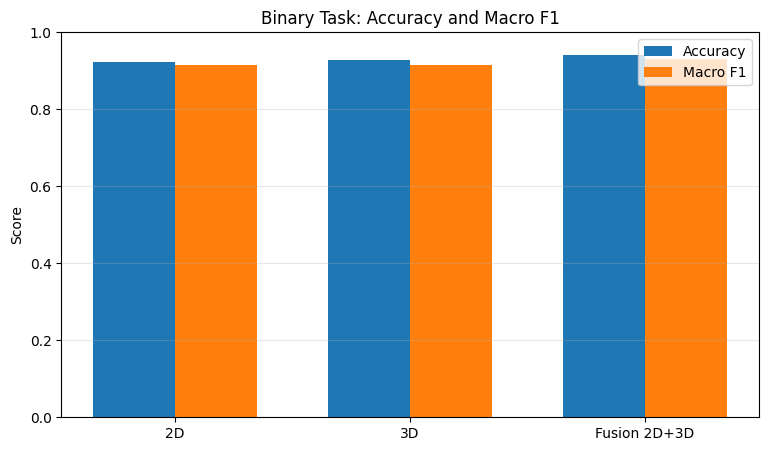

In [24]:
binary_plot_df = summary_df[summary_df["Task"] == "Binary"].copy()

x = np.arange(len(binary_plot_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, binary_plot_df["Accuracy"], width, label="Accuracy")
plt.bar(x + width / 2, binary_plot_df["Macro F1"], width, label="Macro F1")

plt.xticks(x, binary_plot_df["Model"])
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Binary Task: Accuracy and Macro F1")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

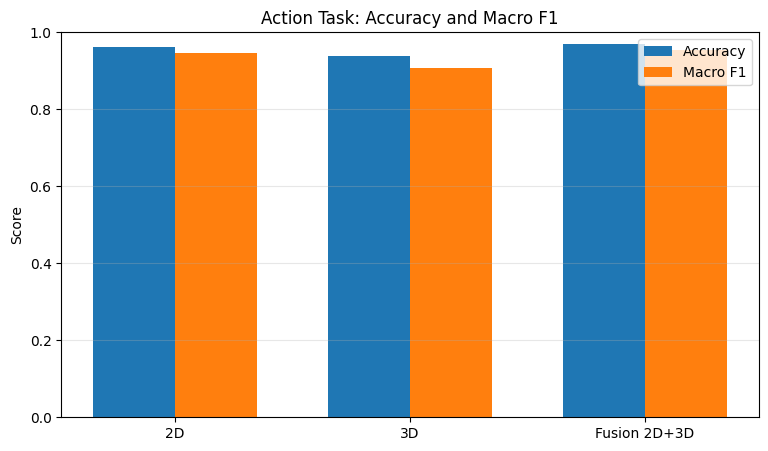

In [25]:
action_plot_df = summary_df[summary_df["Task"] == "Action"].copy()

x = np.arange(len(action_plot_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, action_plot_df["Accuracy"], width, label="Accuracy")
plt.bar(x + width / 2, action_plot_df["Macro F1"], width, label="Macro F1")

plt.xticks(x, action_plot_df["Model"])
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Action Task: Accuracy and Macro F1")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

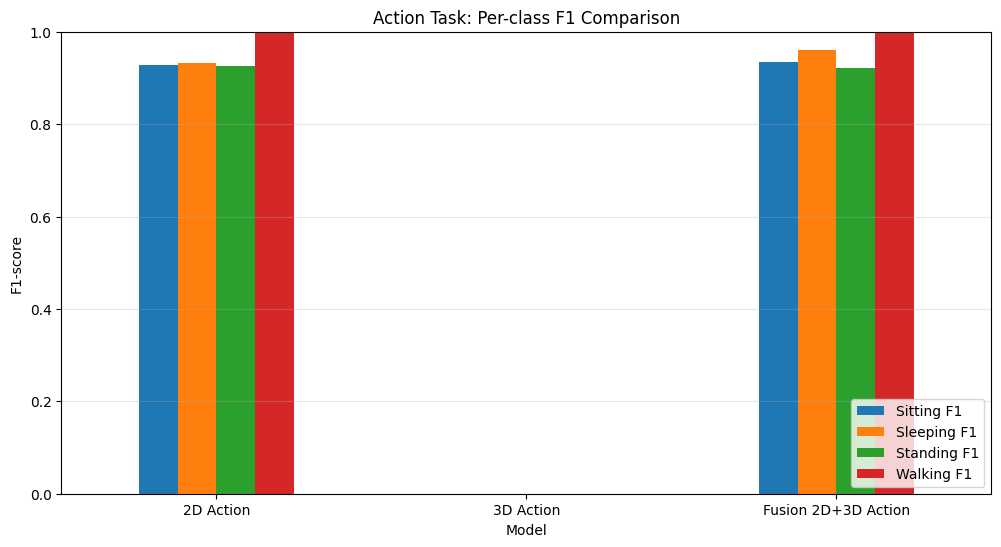

In [26]:
class_cols = ["Sitting F1", "Sleeping F1", "Standing F1", "Walking F1"]

plot_df = action_df.set_index("Model")[class_cols]

ax = plot_df.plot(kind="bar", figsize=(12, 6))
plt.ylim(0, 1.0)
plt.ylabel("F1-score")
plt.title("Action Task: Per-class F1 Comparison")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.show()

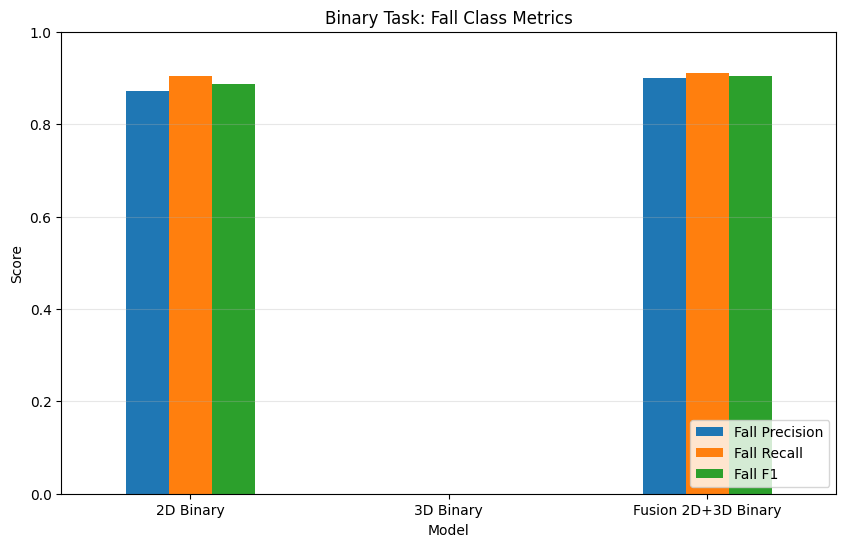

In [27]:
fall_cols = ["Fall Precision", "Fall Recall", "Fall F1"]

plot_df = binary_df.set_index("Model")[fall_cols]

ax = plot_df.plot(kind="bar", figsize=(10, 6))
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Binary Task: Fall Class Metrics")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.show()

In [28]:
def plot_confusion_matrix(cm, class_names, title):
    cm = np.asarray(cm)

    if cm.size == 0:
        print("No confusion matrix available:", title)
        return

    fig, ax = plt.subplots(figsize=(7, 6))

    # Use Blues so high values are darker and easier to read
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")

    ax.set_title(title, fontsize=14, fontweight="bold")
    fig.colorbar(im, ax=ax)

    tick_marks = np.arange(len(class_names))

    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)

    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

    # Add value + row percentage inside each cell
    for i in range(cm.shape[0]):
        row_sum = cm[i].sum()

        for j in range(cm.shape[1]):
            value = cm[i, j]

            if row_sum > 0:
                percent = value / row_sum * 100
            else:
                percent = 0

            # Get cell background color brightness
            rgba = im.cmap(im.norm(value))
            r, g, b, _ = rgba
            luminance = 0.299 * r + 0.587 * g + 0.114 * b

            # If background is bright, use black text.
            # If background is dark, use white text.
            text_color = "black" if luminance > 0.55 else "white"

            ax.text(
                j,
                i,
                f"{value}\n{percent:.1f}%",
                ha="center",
                va="center",
                color=text_color,
                fontsize=12,
                fontweight="bold"
            )

    ax.grid(False)
    plt.tight_layout()
    plt.show()

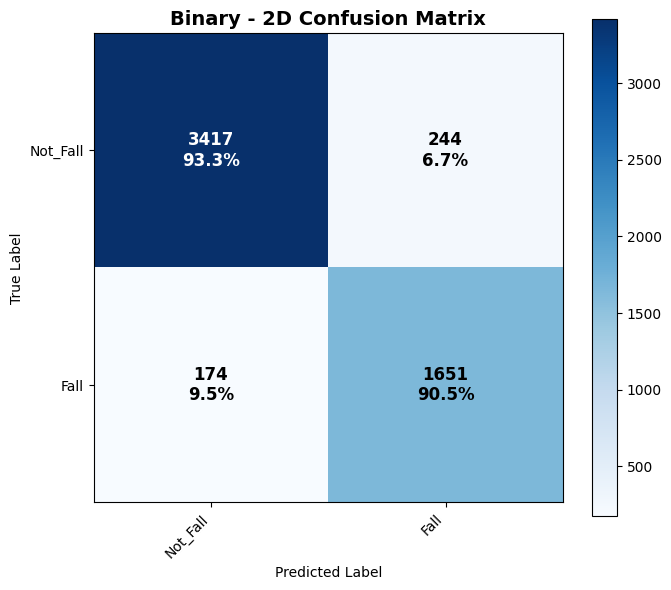

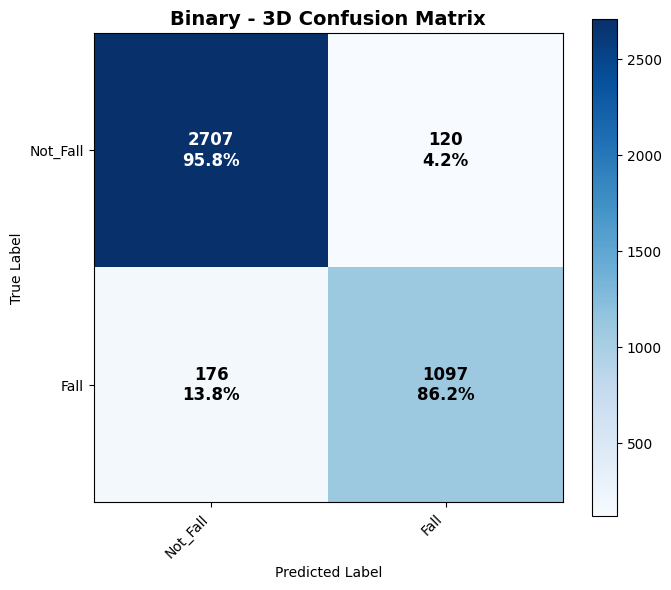

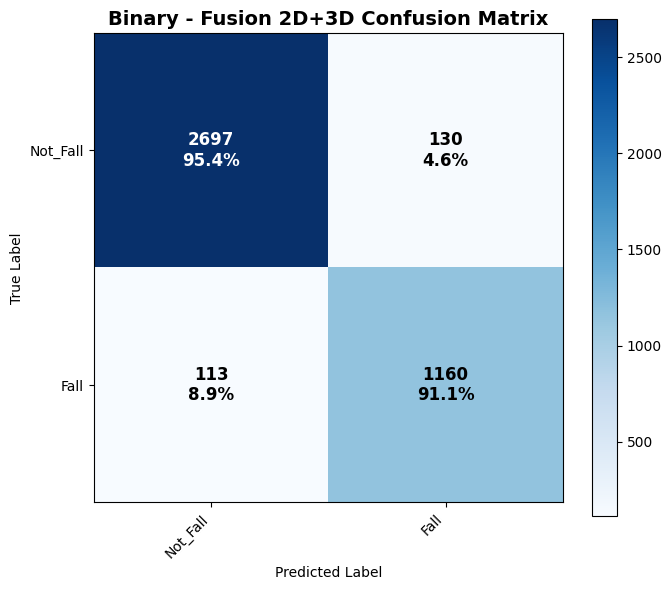

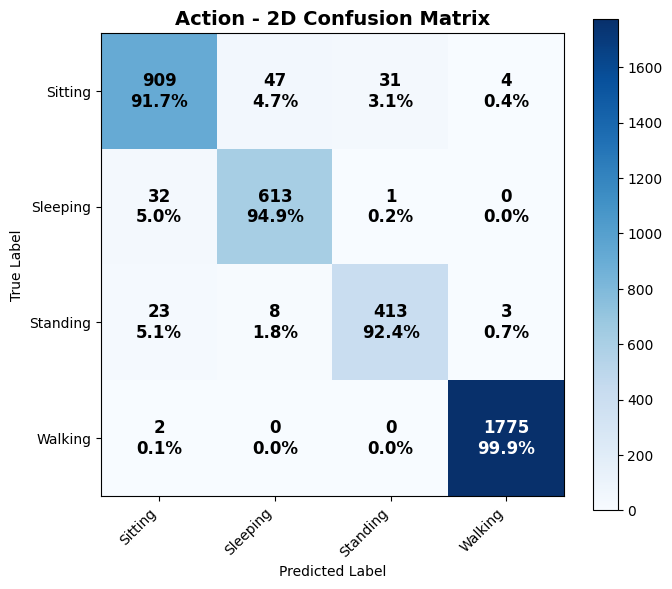

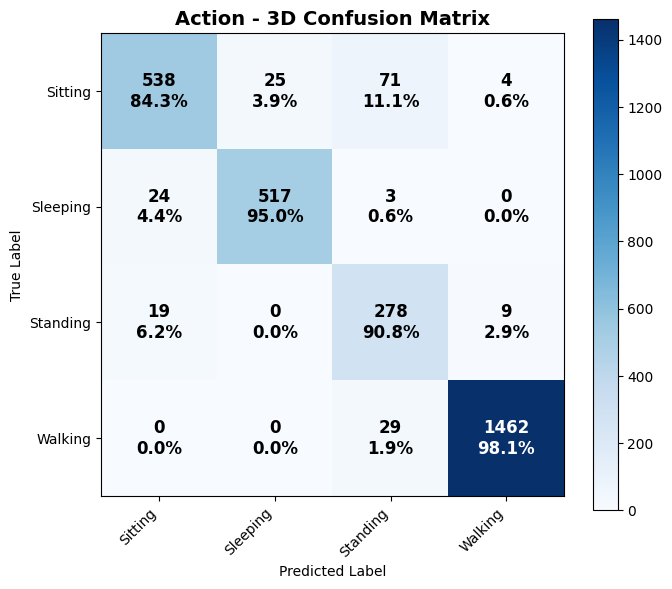

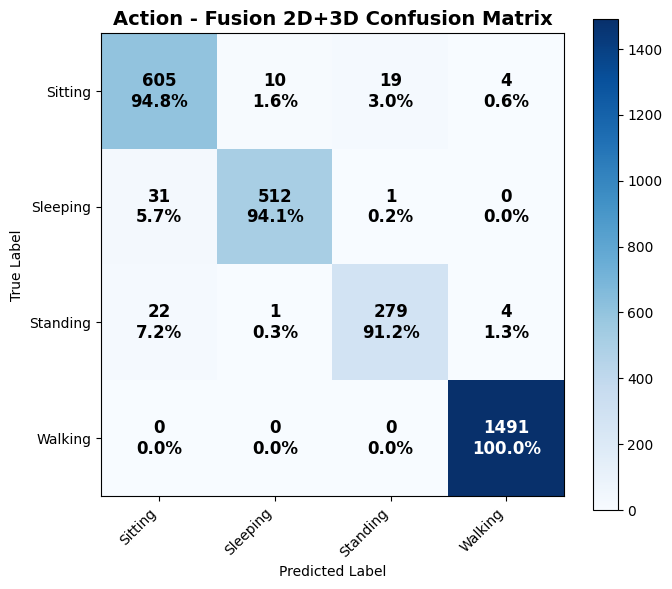

In [29]:
for r in records:
    data = r["data"]

    cm = get_confusion_matrix(data)
    class_names = data.get("class_names", [])

    title = f'{r["task"]} - {r["model"]} Confusion Matrix'

    plot_confusion_matrix(cm, class_names, title)

In [30]:
binary_best_acc = binary_df.loc[binary_df["Accuracy"].idxmax()]
binary_best_f1 = binary_df.loc[binary_df["Macro F1"].idxmax()]

action_best_acc = action_df.loc[action_df["Accuracy"].idxmax()]
action_best_f1 = action_df.loc[action_df["Macro F1"].idxmax()]

report_text = f"""
MODEL COMPARISON CONCLUSION

1. Binary Task - Fall / Not_Fall

For the Fall/Not_Fall classification task, the model with the highest Accuracy is {binary_best_acc["Model"]}, 
achieving an Accuracy of {binary_best_acc["Accuracy"]:.4f}.

The model with the highest Macro F1-score is {binary_best_f1["Model"]}, 
achieving a Macro F1-score of {binary_best_f1["Macro F1"]:.4f}.

The results show that combining 2D and 3D features can help the model learn a more complete representation of human pose. 
In particular, the Fusion 2D+3D model benefits from both the geometric information of 2D keypoints in the image plane 
and the spatial information provided by estimated 3D pose.

2. Action Task - Sitting / Sleeping / Standing / Walking

For the action classification task, the model with the highest Accuracy is {action_best_acc["Model"]}, 
achieving an Accuracy of {action_best_acc["Accuracy"]:.4f}.

The model with the highest Macro F1-score is {action_best_f1["Model"]}, 
achieving a Macro F1-score of {action_best_f1["Macro F1"]:.4f}.

Overall, the Fusion 2D+3D model achieves the best performance in the current experiment. 
The standalone 3D model does not always outperform the 2D model, possibly because the 3D pose is estimated by PoseFormerV2 
rather than obtained from ground-truth 3D annotations. Therefore, errors from 2D pose detection and 2D-to-3D lifting 
may affect the final 3D representation.

However, when 2D and 3D features are concatenated, the two types of information complement each other. 
As a result, the Fusion 2D+3D model improves the overall classification performance compared with using only 2D or only 3D input.
"""

print(report_text)


MODEL COMPARISON CONCLUSION

1. Binary Task - Fall / Not_Fall

For the Fall/Not_Fall classification task, the model with the highest Accuracy is Fusion 2D+3D Binary, 
achieving an Accuracy of 0.9407.

The model with the highest Macro F1-score is Fusion 2D+3D Binary, 
achieving a Macro F1-score of 0.9310.

The results show that combining 2D and 3D features can help the model learn a more complete representation of human pose. 
In particular, the Fusion 2D+3D model benefits from both the geometric information of 2D keypoints in the image plane 
and the spatial information provided by estimated 3D pose.

2. Action Task - Sitting / Sleeping / Standing / Walking

For the action classification task, the model with the highest Accuracy is Fusion 2D+3D Action, 
achieving an Accuracy of 0.9691.

The model with the highest Macro F1-score is Fusion 2D+3D Action, 
achieving a Macro F1-score of 0.9532.

Overall, the Fusion 2D+3D model achieves the best performance in the current experiment. 
The s

In [31]:
output_dir = PROJECT_ROOT / "phase2_3d_upgrade" / "outputs" / "comparison_results"
output_dir.mkdir(parents=True, exist_ok=True)

summary_path = output_dir / "summary_2d_3d_fusion.csv"
binary_path = output_dir / "binary_metrics_2d_3d_fusion.csv"
action_path = output_dir / "action_metrics_2d_3d_fusion.csv"

summary_df.to_csv(summary_path, index=False)
binary_df.to_csv(binary_path, index=False)
action_df.to_csv(action_path, index=False)

print("Saved:")
print(summary_path)
print(binary_path)
print(action_path)

Saved:
c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\outputs\comparison_results\summary_2d_3d_fusion.csv
c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\outputs\comparison_results\binary_metrics_2d_3d_fusion.csv
c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\outputs\comparison_results\action_metrics_2d_3d_fusion.csv
